Using device: cpu
CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(4, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): ReLU()
  )
  (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=1, bias=True)
  )
)
  Epoch 10/50  loss=0.000457
  Epoch 20/50  loss=0.000379
  Epoch 30/50  loss=0.000398
  Epoch 40/50  loss=0.000351
  Epoch 50/50  loss=0.000290

Test RMSE : 15.0018
Test MAE  : 11.6504


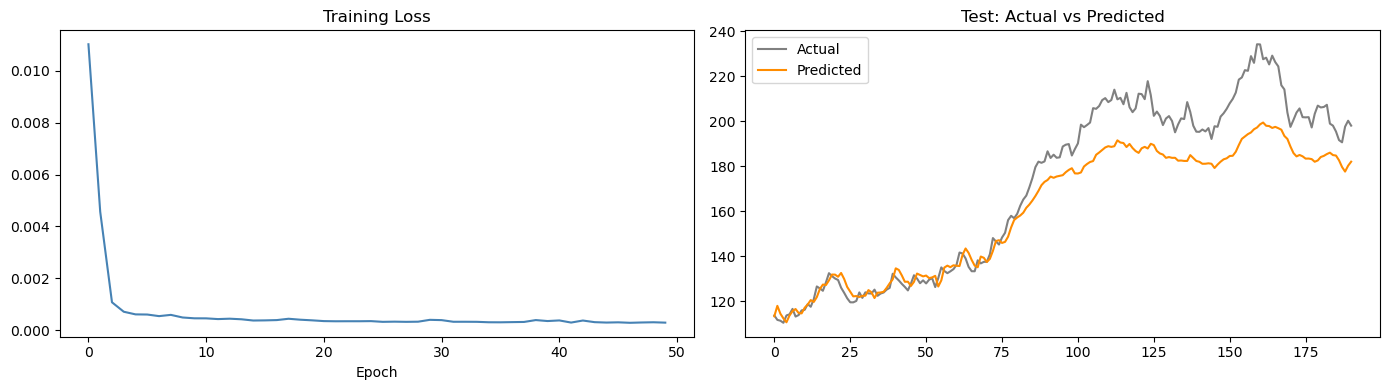

Plot saved → result.png


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


def generate_stock_data(n=1000):
    np.random.seed(42)
    price = [100.0]
    for _ in range(n - 1):
        change = np.random.normal(0.0005, 0.02)
        price.append(price[-1] * (1 + change))

    dates = pd.bdate_range("2020-01-01", periods=n)
    df = pd.DataFrame({"Close": price}, index=dates)

    
    df["MA5"]  = df["Close"].rolling(5).mean()
    df["MA20"] = df["Close"].rolling(20).mean()
    df["RSI"]  = compute_rsi(df["Close"])
    df.dropna(inplace=True)
    return df


def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - 100 / (1 + rs)


class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


def prepare_data(df, seq_len=30, train_ratio=0.8):
    features = ["Close", "MA5", "MA20", "RSI"]
    data = df[features].values

    scaler = MinMaxScaler()
    data   = scaler.fit_transform(data)

    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])      
        y.append(data[i, 0])                  

    X, y = np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

    split = int(len(X) * train_ratio)
    train_ds = StockDataset(X[:split], y[:split])
    test_ds  = StockDataset(X[split:], y[split:])
    return train_ds, test_ds, scaler


class CNNLSTM(nn.Module):
    def __init__(self, n_features, seq_len):
        super().__init__()


        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
        )


        self.lstm = nn.LSTM(input_size=64, hidden_size=64,
                            num_layers=2, batch_first=True, dropout=0.2)

        
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        
        x = x.permute(0, 2, 1)          
        x = self.cnn(x)                 
        x = x.permute(0, 2, 1)         
        x, _ = self.lstm(x)             
        x = x[:, -1, :]                 
        return self.fc(x)               

    
def train(model, train_ds, epochs=50, batch_size=32, lr=1e-3):
    loader    = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / len(loader)
        losses.append(avg)
        if epoch % 10 == 0:
            print(f"  Epoch {epoch}/{epochs}  loss={avg:.6f}")

    return losses


@torch.no_grad()
def evaluate(model, test_ds, scaler):
    loader = DataLoader(test_ds, batch_size=256, shuffle=False)
    preds, trues = [], []
    model.eval()
    for X, y in loader:
        preds.append(model(X.to(device)).cpu().numpy())
        trues.append(y.numpy())

    preds = np.concatenate(preds).flatten()
    trues = np.concatenate(trues).flatten()

    # inverse-scale only the Close column (index 0)
    n = len(preds)
    dummy = np.zeros((n, scaler.n_features_in_))
    dummy[:, 0] = preds;  preds_inv = scaler.inverse_transform(dummy)[:, 0]
    dummy[:, 0] = trues;  trues_inv = scaler.inverse_transform(dummy)[:, 0]

    rmse = math.sqrt(mean_squared_error(trues_inv, preds_inv))
    mae  = mean_absolute_error(trues_inv, preds_inv)
    print(f"\nTest RMSE : {rmse:.4f}")
    print(f"Test MAE  : {mae:.4f}")
    return trues_inv, preds_inv


def plot(losses, trues, preds):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(losses, color="steelblue")
    axes[0].set_title("Training Loss");  axes[0].set_xlabel("Epoch")

    axes[1].plot(trues, label="Actual",    color="gray",        lw=1.5)
    axes[1].plot(preds, label="Predicted", color="darkorange",  lw=1.5)
    axes[1].set_title("Test: Actual vs Predicted");  axes[1].legend()

    plt.tight_layout()
    plt.savefig("result.png", dpi=120)
    plt.show()
    print("Plot saved → result.png")

    
SEQ_LEN = 30
EPOCHS  = 50

df                        = generate_stock_data(n=1000)
train_ds, test_ds, scaler = prepare_data(df, seq_len=SEQ_LEN)

model = CNNLSTM(n_features=4, seq_len=SEQ_LEN).to(device)
print(model)

losses       = train(model, train_ds, epochs=EPOCHS)
trues, preds = evaluate(model, test_ds, scaler)
plot(losses, trues, preds)